In [2]:
%load_ext autoreload
%autoreload 2

In [7]:
import sys
sys.path.append("..")

from genome_mining.descarga import descargar_genoma, obtener_rutas_archivos

In [8]:
ruta = descargar_genoma("GCF_017499595.1", carpeta_destino="../datos")
print(f"Genoma descargado en: {ruta}")

El genoma GCF_017499595.1 ya fue descargado previamente, se reutiliza.
Genoma descargado en: ../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1


In [9]:
archivos = obtener_rutas_archivos(ruta, "GCF_017499595.1")
archivos

{'fasta': PosixPath('../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/GCF_017499595.1_MGC_Penvy_1_genomic.fna'),
 'gff': PosixPath('../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/genomic.gff'),
 'proteinas': PosixPath('../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/protein.faa')}

In [10]:
from genome_mining.blast_utils import descargar_secuencias_referencia, construir_base_blast, correr_blast

genes_interes = {
    "PsiD": "P0DPA6",
    "PsiH": "P0DPA7",
    "PsiK": "P0DPA8",
    "PsiM": "P0DPA9",
}

ruta_referencias = descargar_secuencias_referencia(genes_interes, "../resultados/psilocybe_cubensis/referencias.fasta")

PsiD (P0DPA6) descargado correctamente
PsiH (P0DPA7) descargado correctamente
PsiK (P0DPA8) descargado correctamente
PsiM (P0DPA9) descargado correctamente


In [11]:
ruta_db = construir_base_blast(archivos["proteinas"], "../resultados/psilocybe_cubensis/blast_db/proteinas")



Building a new DB, current time: 07/08/2026 18:15:28
New DB name:   /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
New DB title:  ../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/protein.faa
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 13330 sequences in 0.139319 seconds.




Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


In [12]:
resultados = correr_blast(ruta_referencias, ruta_db, "../resultados/psilocybe_cubensis/blast_resultados.tsv")
resultados[resultados["identidad"] == 100.0]

Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


,query,hit,identidad,longitud,evalue,bitscore,descripcion
0,sp|P0DPA6|PSID_PSICU,XP_047744498.1,100.0,439,0.0,917.0,XP_047744498.1 L-tryptophan decarboxylase [Psi...
8,sp|P0DPA7|PSIH_PSICU,XP_047744495.1,100.0,438,0.0,908.0,XP_047744495.1 Tryptamine 4-monooxygenase [Psi...
101,sp|P0DPA8|PSIK_PSICU,XP_047744494.1,100.0,362,0.0,759.0,XP_047744494.1 Major facilitator-type transpor...
103,sp|P0DPA9|PSIM_PSICU,XP_047744497.1,100.0,309,0.0,642.0,XP_047744497.1 Psilocybin synthase [Psilocybe ...


In [13]:
from genome_mining.visualizacion import extraer_coordenadas, graficar_cluster

# Mapeamos nombre de gen -> accession de proteína (usando los resultados de 100% identidad)
accesiones_confirmadas = {
    "PsiD": "XP_047744498.1",
    "PsiH": "XP_047744495.1",
    "PsiK": "XP_047744494.1",
    "PsiM": "XP_047744497.1",
}

coordenadas = extraer_coordenadas(archivos["gff"], accesiones_confirmadas)
coordenadas

{'PsiD': {'inicio': 1676182, 'fin': 1677607, 'hebra': '-'},
 'PsiH': {'inicio': 1667511, 'fin': 1669282, 'hebra': '+'},
 'PsiK': {'inicio': 1663425, 'fin': 1667194, 'hebra': '+'},
 'PsiM': {'inicio': 1673493, 'fin': 1675081, 'hebra': '-'}}

Gráfico guardado en: ../resultados/psilocybe_cubensis/cluster.png


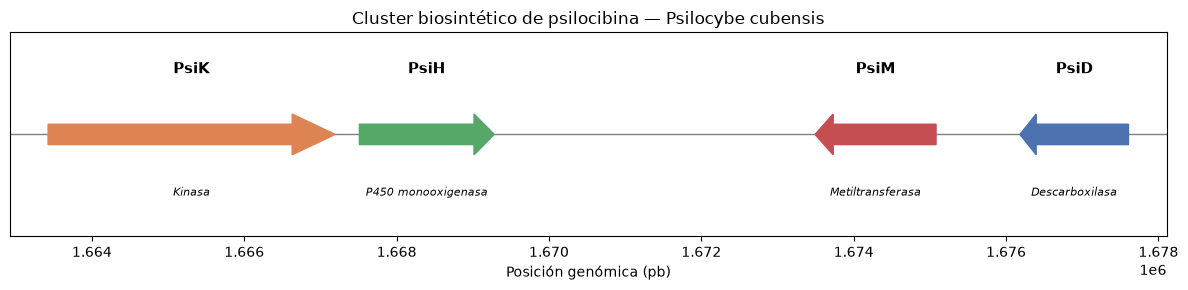

In [14]:
productos = {"PsiD": "Descarboxilasa", "PsiH": "P450 monooxigenasa", "PsiK": "Kinasa", "PsiM": "Metiltransferasa"}

graficar_cluster(
    coordenadas,
    titulo="Cluster biosintético de psilocibina — Psilocybe cubensis",
    productos=productos,
    ruta_salida="../resultados/psilocybe_cubensis/cluster.png"
)

--- Analizando Psilocybe cubensis ---
Descargando genoma...
El genoma GCF_017499595.1 ya fue descargado previamente, se reutiliza.
Descargando secuencias de referencia...
PsiD (P0DPA6) descargado correctamente
PsiH (P0DPA7) descargado correctamente
PsiK (P0DPA8) descargado correctamente
PsiM (P0DPA9) descargado correctamente
Construyendo base de datos BLAST...


Building a new DB, current time: 07/08/2026 18:15:35
New DB name:   /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
New DB title:  datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/protein.faa
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 13330 sequences in 0.141986 seconds.




Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Corriendo BLAST...


Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Se encontraron 4 matches con 100% de identidad
Extrayendo coordenadas del GFF3...
Generando visualización...
Gráfico guardado en: ../resultados/psilocybe_cubensis/cluster.png


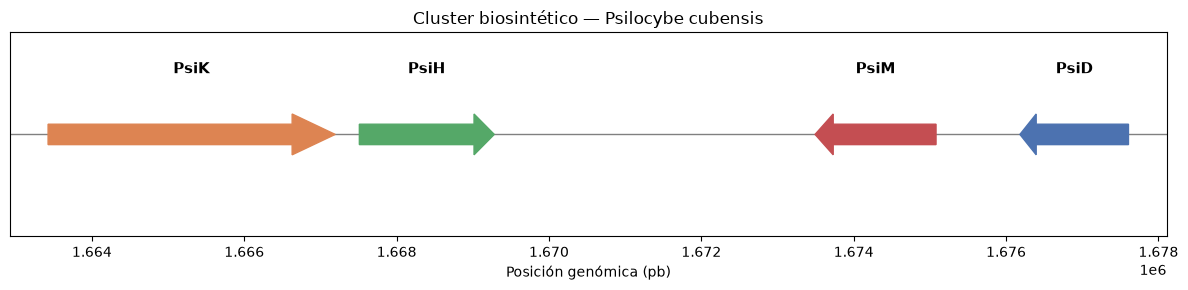

In [15]:
from genome_mining.pipeline import analizar_especie

coordenadas = analizar_especie("psilocybe_cubensis", config_path="../config/especies.yaml", carpeta_resultados="../resultados")

In [16]:
import sys
sys.path.append("..")

In [2]:
import sys
sys.path.append("..")

In [3]:
from genome_mining.pipeline import agregar_especie

In [4]:
agregar_especie(
    nombre_cientifico="Cordyceps militaris",
    genes_interes={
        "Cns1": "G3JF08",
    },
    config_path="../config/especies.yaml"
)

Accession seleccionado automáticamente: GCA_008080495.1 (N50: 5,778,387 bp)
Especie 'cordyceps_militaris' agregada/actualizada en ../config/especies.yaml


'cordyceps_militaris'